# MAT_SCI 465 Final Project
## Data Efficiency in Deep Learning for TEM Nanoparticle Segmentation

This notebook:
1. Runs a **classical segmentation baseline** (Gaussian → CLAHE → Otsu → Watershed).
2. Trains a **U-Net (PyTorch)** for multiple labeled set sizes.
3. Evaluates **IoU / Dice** on a fixed test set.
4. Produces a **learning curve** and estimates the **crossover (break-even) label count**.
5. Converts label count into **annotation time** to judge whether extra labeling effort is justified.

In [67]:
from pathlib import Path

# Dataset location
DATA_DIR = Path.home() / "Desktop" / "465" / "raw_data"
LABEL_DIR = Path.home() / "Desktop" / "465" / "labels"

print("DATA_DIR:", DATA_DIR)
print("LABEL_DIR:", LABEL_DIR)
print("Images folder exists:", DATA_DIR.exists())
print("Labels folder exists:", LABEL_DIR.exists())


DATA_DIR: /Users/jeremylee/Desktop/465/raw_data
LABEL_DIR: /Users/jeremylee/Desktop/465/labels
Images folder exists: True
Labels folder exists: True


In [68]:
from pathlib import Path
import os, zipfile, random, warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 465
random.seed(SEED)
np.random.seed(SEED)

DATA_ZIP = None

# Use the x-image dataset
DATA_DIR = Path.home() / "Desktop" / "465" / "40_images"
LABEL_DIR = Path.home() / "Desktop" / "465" / "40_labels"

OUT_DIR = Path.home() / "Desktop" / "465" / "outputs"
OUT_DIR.mkdir(exist_ok=True)

In [69]:
# Collect images and labels
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Could not find image folder: {DATA_DIR}")

image_paths = sorted([p for p in DATA_DIR.glob('*.png') if p.is_file()])
print(f"Found {len(image_paths)} images in {DATA_DIR.resolve()}")
assert len(image_paths) > 0, f'No PNG images found in {DATA_DIR}'

label_paths = {}
if LABEL_DIR.exists():
    for lp in LABEL_DIR.glob('*.png'):
        label_paths[lp.name] = lp
print(f"Found {len(label_paths)} label masks in {LABEL_DIR.resolve() if LABEL_DIR.exists() else LABEL_DIR}")

Found 40 images in /Users/jeremylee/Desktop/465/40_images
Found 40 label masks in /Users/jeremylee/Desktop/465/40_labels


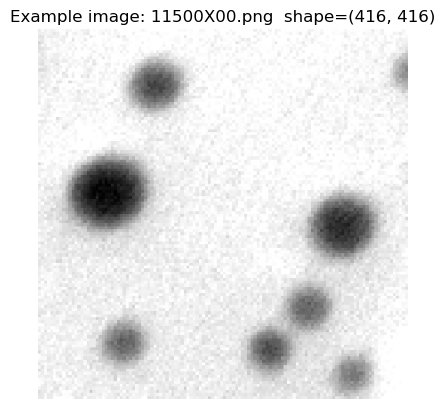

In [70]:
from PIL import Image

def read_gray(path: Path):
    img = Image.open(path).convert("L")
    return np.array(img)

def read_mask(path: Path):
    m = Image.open(path).convert("L")
    m = np.array(m)
    return (m > 127).astype(np.uint8)

# Quick view
idx = 0
img0 = read_gray(image_paths[idx])
plt.figure()
plt.imshow(img0, cmap='gray')
plt.title(f"Example image: {image_paths[idx].name}  shape={img0.shape}")
plt.axis('off')
plt.show()

In [71]:
from skimage import exposure, filters, morphology, measure, segmentation
from scipy import ndimage as ndi

# Classical pipeline
def classical_segment(image_u8: np.ndarray,
                      sigma: float = 1.0,
                      clahe_clip: float = 0.01,
                      min_size: int = 10,
                      dark_objects: bool = True):
    img = image_u8.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    blurred = filters.gaussian(img, sigma=sigma)
    enhanced = exposure.equalize_adapthist(blurred, clip_limit=clahe_clip)

    thr = filters.threshold_otsu(enhanced)
    binary = enhanced < thr if dark_objects else enhanced > thr

    binary = morphology.remove_small_objects(binary, min_size=min_size)
    binary = morphology.remove_small_holes(binary, area_threshold=min_size)

    distance = ndi.distance_transform_edt(binary)
    coords = morphology.local_maxima(distance)
    markers = measure.label(coords)

    labels = segmentation.watershed(-distance, markers, mask=binary)
    mask = (labels > 0).astype(np.uint8)

    return {
        'blurred': blurred,
        'enhanced': enhanced,
        'threshold': thr,
        'binary': binary.astype(np.uint8),
        'mask': mask,
        'labels': labels
    }

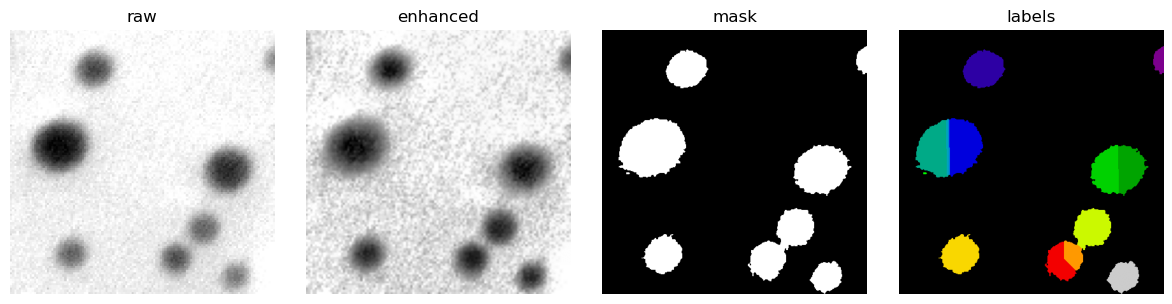

In [72]:
# Visualization
img_example = read_gray(image_paths[0])
res = classical_segment(img_example)

plt.figure(figsize=(12,3))
for i, (k, v) in enumerate([
    ('raw', img_example),
    ('enhanced', res['enhanced']),
    ('mask', res['mask']),
    ('labels', res['labels'])
]):
    plt.subplot(1, 4, i+1)
    plt.imshow(v, cmap='nipy_spectral' if k == 'labels' else 'gray')
    plt.title(k)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [73]:
def iou_dice(pred: np.ndarray, gt: np.ndarray):
    pred = (pred>0).astype(np.uint8)
    gt = (gt>0).astype(np.uint8)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    iou = inter / (union + 1e-8)
    dice = (2*inter) / (pred.sum() + gt.sum() + 1e-8)
    return float(iou), float(dice)

# If no labels exist, generate pseudo-labels from classical method
PSEUDO_DIR = OUT_DIR / 'labels_pseudo'
use_pseudo = False
if len(label_paths)==0:
    use_pseudo = True
    PSEUDO_DIR.mkdir(exist_ok=True)
    for p in image_paths:
        m = classical_segment(read_gray(p))['mask']
        Image.fromarray((m*255).astype(np.uint8)).save(PSEUDO_DIR / p.name)
    label_paths = {p.name: (PSEUDO_DIR / p.name) for p in image_paths}
    print(f"No manual labels found. Generated pseudo-labels in {PSEUDO_DIR}")
else:
    print("Using manual labels from labels/")

paired = [(p, label_paths.get(p.name, None)) for p in image_paths]
paired = [(p,l) for p,l in paired if l is not None]
print(f"Paired images+labels: {len(paired)}")
assert len(paired) >= 20, "Need at least 20 paired images/masks for the requested train sizes."

Using manual labels from labels/
Paired images+labels: 40


In [82]:
N_TEST = 8
N_VAL = 8

random.shuffle(paired)

test_pairs = paired[:N_TEST]
val_pairs = paired[N_TEST:N_TEST+N_VAL]
train_pool = paired[N_TEST+N_VAL:]

print(f"Train pool: {len(train_pool)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")
assert len(train_pool) >= 24, "Training pool must have at least 30 labeled images."

Train pool: 24, Val: 8, Test: 8


In [83]:
# Classical baseline evaluation on the TEST set
classical_ious=[]
classical_dices=[]
for img_p, lab_p in test_pairs:
    img = read_gray(img_p)
    gt = read_mask(lab_p)
    pred = classical_segment(img, dark_objects=True)['mask']
    iou, dice = iou_dice(pred, gt)
    classical_ious.append(iou)
    classical_dices.append(dice)

baseline_iou = float(np.mean(classical_ious))
baseline_dice = float(np.mean(classical_dices))
print(f"Classical baseline (Watershed, dark-object Otsu) on test: IoU={baseline_iou:.4f}, Dice={baseline_dice:.4f}")

Classical baseline (Watershed, dark-object Otsu) on test: IoU=0.8423, Dice=0.9140


In [84]:
## import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

# Resize
TARGET_SIZE = (256, 256)  # (H,W)

class TEMSegDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.pairs = pairs
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, lab_p = self.pairs[idx]
        img = read_gray(img_p)
        msk = read_mask(lab_p)

        img = np.array(Image.fromarray(img).resize(TARGET_SIZE[::-1], Image.BILINEAR))
        msk = np.array(Image.fromarray((msk * 255).astype(np.uint8)).resize(TARGET_SIZE[::-1], Image.NEAREST))
        msk = (msk > 127).astype(np.uint8)

        img = img.astype(np.float32)
        img = (img - img.min())/(img.max()-img.min()+1e-8)

        if self.augment:
            # simple augmentations: flips
            if random.random() < 0.5:
                img = np.flip(img, axis=1).copy(); msk = np.flip(msk, axis=1).copy()
            if random.random() < 0.5:
                img = np.flip(img, axis=0).copy(); msk = np.flip(msk, axis=0).copy()

        img_t = torch.from_numpy(img).unsqueeze(0)  # [1,H,W]
        msk_t = torch.from_numpy(msk.astype(np.float32)).unsqueeze(0)
        return img_t, msk_t

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self,x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.d1 = DoubleConv(in_ch, base)
        self.p1 = nn.MaxPool2d(2)
        self.d2 = DoubleConv(base, base*2)
        self.p2 = nn.MaxPool2d(2)
        self.d3 = DoubleConv(base*2, base*4)
        self.p3 = nn.MaxPool2d(2)

        self.mid = DoubleConv(base*4, base*8)

        self.u3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.c3 = DoubleConv(base*8, base*4)
        self.u2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.c2 = DoubleConv(base*4, base*2)
        self.u1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.c1 = DoubleConv(base*2, base)

        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self,x):
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.d3(self.p2(x2))
        xm = self.mid(self.p3(x3))

        y3 = self.u3(xm)
        y3 = torch.cat([y3, x3], dim=1)
        y3 = self.c3(y3)

        y2 = self.u2(y3)
        y2 = torch.cat([y2, x2], dim=1)
        y2 = self.c2(y2)

        y1 = self.u1(y2)
        y1 = torch.cat([y1, x1], dim=1)
        y1 = self.c1(y1)

        return self.out(y1)

# Loss
bce = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets):
    probs = torch.sigmoid(logits)
    num = 2*(probs*targets).sum(dim=(2,3))
    den = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + 1e-8
    dice = num/den
    return 1 - dice.mean()

def loss_fn(logits, targets):
    return 0.5*bce(logits, targets) + 0.5*dice_loss(logits, targets)

Device: cpu


In [85]:
def eval_model(model, pairs):
    model.eval()
    ds = TEMSegDataset(pairs, augment=False)
    dl = DataLoader(ds, batch_size=1, shuffle=False)
    ious=[]; dices=[]
    with torch.no_grad():
        for x,y in dl:
            x=x.to(DEVICE); y=y.to(DEVICE)
            logits = model(x)
            pred = (torch.sigmoid(logits) > 0.5).float()
            # compute metrics on CPU
            p = pred.squeeze().cpu().numpy().astype(np.uint8)
            g = y.squeeze().cpu().numpy().astype(np.uint8)
            iou, dice = iou_dice(p, g)
            ious.append(iou); dices.append(dice)
    return float(np.mean(ious)), float(np.mean(dices))

def train_unet(train_pairs, val_pairs, epochs=20, lr=1e-3, batch_size=4):
    model = UNet().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    train_ds = TEMSegDataset(train_pairs, augment=True)
    val_ds = TEMSegDataset(val_pairs, augment=False)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=1, shuffle=False)

    best_val = -1
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        losses=[]
        for x,y in train_dl:
            x=x.to(DEVICE); y=y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        val_iou, val_dice = eval_model(model, val_pairs)
        if val_iou > best_val:
            best_val = val_iou
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}

        if ep % 5 == 0 or ep==1:
            print(f"Epoch {ep:02d}/{epochs} | train loss={np.mean(losses):.4f} | val IoU={val_iou:.4f} Dice={val_dice:.4f}")

    # restore best
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

In [87]:
# Data efficiency
TRAIN_SIZES = [4, 8, 16, 24]
N_REPEATS = 5  # run multiple seeds to estimate stability
EPOCHS = 25

results = []

for n in TRAIN_SIZES:
    if len(train_pool) < n:
        print(f"Skipping n={n} (train pool too small)")
        continue

    scores_iou=[]; scores_dice=[]
    for r in range(N_REPEATS):
        random.shuffle(train_pool)
        train_pairs = train_pool[:n]

        torch.manual_seed(SEED + 1000*n + r)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + 1000*n + r)

        model = train_unet(train_pairs, val_pairs, epochs=EPOCHS, lr=1e-3, batch_size=4)
        test_iou, test_dice = eval_model(model, test_pairs)
        scores_iou.append(test_iou)
        scores_dice.append(test_dice)
        print(f"n={n:02d} repeat={r+1} -> TEST IoU={test_iou:.4f}, Dice={test_dice:.4f}")

    results.append({
        'train_images': n,
        'test_iou_mean': float(np.mean(scores_iou)),
        'test_iou_std': float(np.std(scores_iou, ddof=1) if len(scores_iou)>1 else 0.0),
        'test_dice_mean': float(np.mean(scores_dice)),
        'test_dice_std': float(np.std(scores_dice, ddof=1) if len(scores_dice)>1 else 0.0),
    })

results

Epoch 01/25 | train loss=0.7475 | val IoU=0.0000 Dice=0.0000
Epoch 05/25 | train loss=0.5544 | val IoU=0.0000 Dice=0.0000
Epoch 10/25 | train loss=0.4997 | val IoU=0.0000 Dice=0.0000
Epoch 15/25 | train loss=0.4734 | val IoU=0.3199 Dice=0.4798
Epoch 20/25 | train loss=0.4577 | val IoU=0.6535 Dice=0.7871
Epoch 25/25 | train loss=0.4440 | val IoU=0.5173 Dice=0.6775
n=04 repeat=1 -> TEST IoU=0.6227, Dice=0.7602
Epoch 01/25 | train loss=0.7692 | val IoU=0.1031 Dice=0.1855
Epoch 05/25 | train loss=0.5542 | val IoU=0.1492 Dice=0.2531
Epoch 10/25 | train loss=0.4999 | val IoU=0.0793 Dice=0.1456
Epoch 15/25 | train loss=0.4723 | val IoU=0.2062 Dice=0.3381
Epoch 20/25 | train loss=0.4525 | val IoU=0.3394 Dice=0.5025
Epoch 25/25 | train loss=0.4346 | val IoU=0.4063 Dice=0.5750
n=04 repeat=2 -> TEST IoU=0.3798, Dice=0.5424
Epoch 01/25 | train loss=0.7947 | val IoU=0.0000 Dice=0.0000
Epoch 05/25 | train loss=0.5322 | val IoU=0.0000 Dice=0.0000
Epoch 10/25 | train loss=0.4868 | val IoU=0.2008 Dice=

[{'train_images': 4,
  'test_iou_mean': 0.5181913023671184,
  'test_iou_std': 0.14230252760158496,
  'test_dice_mean': 0.6671436405441221,
  'test_dice_std': 0.12263010623499268},
 {'train_images': 8,
  'test_iou_mean': 0.9110018892136618,
  'test_iou_std': 0.0206696702652835,
  'test_dice_mean': 0.9530755941640751,
  'test_dice_std': 0.011535918735197617},
 {'train_images': 16,
  'test_iou_mean': 0.9284864909831414,
  'test_iou_std': 0.004170055872807,
  'test_dice_mean': 0.9628007920336111,
  'test_dice_std': 0.002277123570919988},
 {'train_images': 24,
  'test_iou_mean': 0.9318862987573588,
  'test_iou_std': 0.013810781293899657,
  'test_dice_mean': 0.9645616335027624,
  'test_dice_std': 0.007560759828513713}]

In [88]:
# Results

results_sorted = sorted(results, key=lambda x: x['train_images'])

print("Results Table")
print(f"{'Train Images':>12}  {'Mean IoU':>10}  {'IoU Std':>8}  {'Mean Dice':>10}  {'Dice Std':>9}  {'ΔIoU vs Classical':>18}  {'ΔDice vs Classical':>19}")

for r in results_sorted:
    delta_iou = r['test_iou_mean'] - baseline_iou
    delta_dice = r['test_dice_mean'] - baseline_dice

    print(f"{r['train_images']:12d}  "
          f"{r['test_iou_mean']:10.4f}  "
          f"{r['test_iou_std']:8.4f}  "
          f"{r['test_dice_mean']:10.4f}  "
          f"{r['test_dice_std']:9.4f}  "
          f"{delta_iou:18.4f}  "
          f"{delta_dice:19.4f}")

print("\nClassical Baseline")
print(f"IoU  = {baseline_iou:.4f}")
print(f"Dice = {baseline_dice:.4f}")

Results Table
Train Images    Mean IoU   IoU Std   Mean Dice   Dice Std   ΔIoU vs Classical   ΔDice vs Classical
           4      0.5182    0.1423      0.6671     0.1226             -0.3241              -0.2469
           8      0.9110    0.0207      0.9531     0.0115              0.0687               0.0391
          16      0.9285    0.0042      0.9628     0.0023              0.0862               0.0488
          24      0.9319    0.0138      0.9646     0.0076              0.0896               0.0505

Classical Baseline
IoU  = 0.8423
Dice = 0.9140


Estimated IoU break-even label count: 7.300198292946874


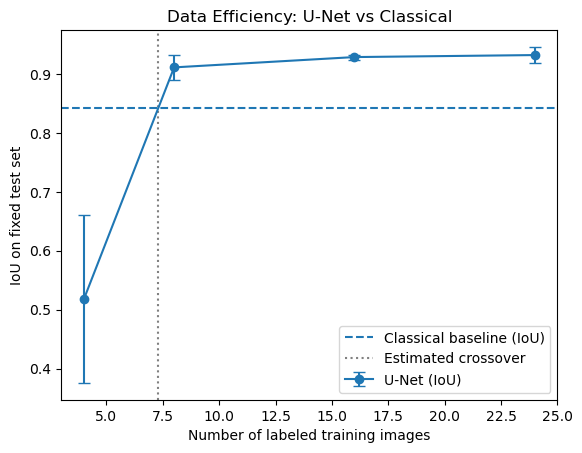

In [89]:
import matplotlib.pyplot as plt

results_sorted = sorted(results, key=lambda x: x['train_images'])

train_images = [r['train_images'] for r in results_sorted]
mean_scores_iou = [r['test_iou_mean'] for r in results_sorted]
std_scores_iou = [r['test_iou_std'] for r in results_sorted]

def estimate_crossover(train_sizes, unet_scores, classical_score):
    for i in range(len(train_sizes) - 1):
        x1, x2 = train_sizes[i], train_sizes[i+1]
        y1, y2 = unet_scores[i], unet_scores[i+1]

        if (y1 - classical_score) * (y2 - classical_score) <= 0:
            slope = (y2 - y1) / (x2 - x1)
            if abs(slope) < 1e-12:
                return float(x1)
            return x1 + (classical_score - y1) / slope
    return None

crossover = estimate_crossover(train_images, mean_scores_iou, baseline_iou)

if crossover is None:
    if mean_scores_iou[0] > baseline_iou:
        print("Estimated IoU break-even label count: < 5")
    else:
        print("No crossover found within tested range")
else:
    print("Estimated IoU break-even label count:", crossover)

plt.figure()
plt.errorbar(train_images, mean_scores_iou, yerr=std_scores_iou, marker='o', capsize=4, label='U-Net (IoU)')
plt.axhline(baseline_iou, linestyle='--', label='Classical baseline (IoU)')

if crossover is not None:
    plt.axvline(crossover, linestyle=':', color='gray', label='Estimated crossover')

plt.xlabel('Number of labeled training images')
plt.ylabel('IoU on fixed test set')
plt.title('Data Efficiency: U-Net vs Classical')
plt.legend()
plt.show()

In [90]:
# Labeling cost

minutes_per_image = 8  # set this to your own average labeling time

def mins_to_hm(mins):
    h = int(mins // 60)
    m = int(round(mins - 60*h))
    return f"{h}h {m}m" if h > 0 else f"{m}m"

results_sorted = sorted(results, key=lambda x: x['train_images'])

if crossover is not None:
    total_mins = crossover * minutes_per_image
    print(f"If annotation takes ~{minutes_per_image} min/image, break-even effort ≈ {total_mins:.0f} min ({mins_to_hm(total_mins)}).")
else:
    print("No crossover found within tested train sizes.")

print("\nSummary:")
print(f"Classical baseline: IoU={baseline_iou:.3f}, Dice={baseline_dice:.3f}")

for r in results_sorted:
    delta_iou = r['test_iou_mean'] - baseline_iou
    delta_dice = r['test_dice_mean'] - baseline_dice
    print(
        f"U-Net @ n={r['train_images']:2d}: "
        f"IoU={r['test_iou_mean']:.3f}±{r['test_iou_std']:.3f} "
        f"(Δ={delta_iou:+.3f}), "
        f"Dice={r['test_dice_mean']:.3f}±{r['test_dice_std']:.3f} "
        f"(Δ={delta_dice:+.3f})"
    )

If annotation takes ~8 min/image, break-even effort ≈ 58 min (58m).

Summary:
Classical baseline: IoU=0.842, Dice=0.914
U-Net @ n= 4: IoU=0.518±0.142 (Δ=-0.324), Dice=0.667±0.123 (Δ=-0.247)
U-Net @ n= 8: IoU=0.911±0.021 (Δ=+0.069), Dice=0.953±0.012 (Δ=+0.039)
U-Net @ n=16: IoU=0.928±0.004 (Δ=+0.086), Dice=0.963±0.002 (Δ=+0.049)
U-Net @ n=24: IoU=0.932±0.014 (Δ=+0.090), Dice=0.965±0.008 (Δ=+0.051)


In [98]:
# Train one final model at the largest tested train size
results_sorted = sorted(results, key=lambda x: x['train_images'])
best_n = max(r['train_images'] for r in results_sorted) if len(results_sorted) > 0 else None

if best_n is not None:
    random.shuffle(train_pool)
    final_train = train_pool[:best_n]

    torch.manual_seed(SEED + 999)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + 999)

    final_model = train_unet(final_train, val_pairs, epochs=EPOCHS, lr=1e-3, batch_size=4)

    ex_dir = OUT_DIR / 'qualitative_examples'
    ex_dir.mkdir(exist_ok=True)

    final_model.eval()
    for i, (img_p, lab_p) in enumerate(test_pairs[:5]):
        img = read_gray(img_p)
        gt = read_mask(lab_p)
        cls = classical_segment(img, dark_objects=True)['mask']

        x = np.array(Image.fromarray(img).resize(TARGET_SIZE[::-1], Image.BILINEAR)).astype(np.float32)
        x = (x - x.min()) / (x.max() - x.min() + 1e-8)

        gt_r = np.array(Image.fromarray((gt * 255).astype(np.uint8)).resize(TARGET_SIZE[::-1], Image.NEAREST))
        cls_r = np.array(Image.fromarray((cls * 255).astype(np.uint8)).resize(TARGET_SIZE[::-1], Image.NEAREST))
        gt_r = (gt_r > 127).astype(np.uint8)
        cls_r = (cls_r > 127).astype(np.uint8)

        xt = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits = final_model(xt)
            pred = (torch.sigmoid(logits) > 0.5).float().squeeze().cpu().numpy().astype(np.uint8)

        fig = plt.figure(figsize=(10, 3))
        for j, (title, arr) in enumerate([
            ('raw', x),
            ('GT', gt_r),
            ('classical', cls_r),
            ('U-Net', pred),
        ]):
            plt.subplot(1, 4, j + 1)
            plt.imshow(arr, cmap='gray')
            plt.title(title)
            plt.axis('off')

        plt.tight_layout()
        out_path = ex_dir / f"example_{i}_{img_p.stem}.png"

        plt.close(fig)

    print(f"Saved examples to {ex_dir}")
else:
    print("No trained model results available to save examples.")

Epoch 01/25 | train loss=0.6000 | val IoU=0.5060 Dice=0.6694
Epoch 05/25 | train loss=0.3847 | val IoU=0.7888 Dice=0.8800
Epoch 10/25 | train loss=0.2992 | val IoU=0.9039 Dice=0.9493
Epoch 15/25 | train loss=0.2327 | val IoU=0.8867 Dice=0.9394
Epoch 20/25 | train loss=0.1752 | val IoU=0.8488 Dice=0.9173
Epoch 25/25 | train loss=0.1296 | val IoU=0.8613 Dice=0.9246
Saved examples to /Users/jeremylee/Desktop/465/outputs/qualitative_examples


# 